In [1]:
import sys
import os

# add src folder to path
sys.path.append(os.path.abspath("../src")) 

from imports import * 

In [2]:
''' 
This notebook performs volatility forecasting using past observations: 
        Historical data is split into training (2014-2023) and test (2024) periods (done)
        A GARCH(1,1) is trained on the returns timeseries (done)
        Model results scored and recored (done)
        Forecast is plotted against true observations (done)

'''

' \nThis notebook performs volatility forecasting using past observations: \n        Historical data is split into training (2014-2023) and test (2024) periods (done)\n        A GARCH(1,1) is trained on the returns timeseries (done)\n        Model results scored and recored (done)\n        Forecast is plotted against true observations (done)\n\n'

In [3]:
# load returns.csv
returns = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)

print(returns.info())
returns

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2734 entries, 2014-01-02 to 2024-06-28
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  2734 non-null   float64
 1   CAD=X     2734 non-null   float64
dtypes: float64(2)
memory usage: 64.1 KB
None


,EURUSD=X,CAD=X
Date,,
2014-01-02,0.237312,0.158325
2014-01-03,0.231106,-0.727065
2014-01-06,-0.361792,-0.516652
2014-01-07,0.285965,0.264468
2014-01-08,1.051503,-0.114382
...,...,...
2024-06-24,0.121303,-0.174209
2024-06-25,-0.316753,0.420722
2024-06-26,0.023427,-0.215266


In [4]:
forecast_name = 'variance' 
data = returns.copy()

In [5]:
tickers = data.columns
tickers

Index(['EURUSD=X', 'CAD=X'], dtype='object')

In [6]:
# Split data into train, and test sets 
train_split = '2023-01-01' 

train = data.loc[:'2022-12-31'] 
test = data.loc[train_split:]

# check
print(train.shape, test.shape)
print(train.index.min(), train.index.max()) 
print(test.index.min(), test.index.max())

print("Train")
print(train) 
print("Test")
print(test)


(2344, 2) (390, 2)
2014-01-02 00:00:00 2022-12-30 00:00:00
2023-01-02 00:00:00 2024-06-28 00:00:00
Train
            EURUSD=X     CAD=X
Date                          
2014-01-02  0.237312  0.158325
2014-01-03  0.231106 -0.727065
2014-01-06 -0.361792 -0.516652
2014-01-07  0.285965  0.264468
2014-01-08  1.051503 -0.114382
...              ...       ...
2022-12-26 -0.345386  0.608058
2022-12-27 -0.240626 -0.258560
2022-12-28 -0.236044 -0.028715
2022-12-29  0.550099 -0.074414
2022-12-30 -0.348545  0.296373

[2344 rows x 2 columns]
Test
            EURUSD=X     CAD=X
Date                          
2023-01-02 -0.176360  0.459449
2023-01-03  0.228415 -0.298977
2023-01-04  0.848875 -1.225540
2023-01-05 -1.382169  0.564248
2023-01-06  0.554688 -0.793367
...              ...       ...
2024-06-24  0.121303 -0.174209
2024-06-25 -0.316753  0.420722
2024-06-26  0.023427 -0.215266
2024-06-27  0.317694 -0.275549
2024-06-28 -0.037943  0.265573

[390 rows x 2 columns]


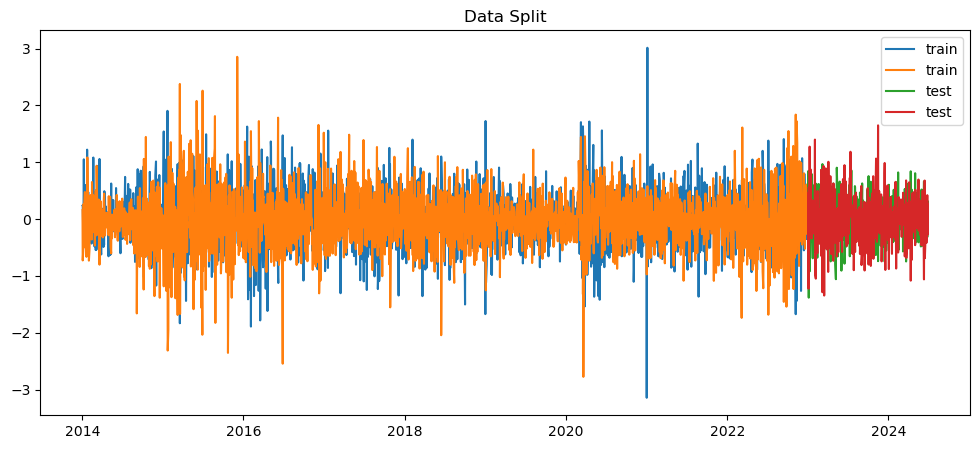

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label="train") 
plt.plot(test.index, test, label="test")

plt.title("Data Split")
plt.legend()
plt.show()

In [8]:
# normalize?

In [9]:
# A first model
model_dict = {}
P, Q = (1, 1)
for ticker in tickers:
    # GARCH(1, 1)
    model = arch_model( train[ticker],
                        vol='Garch',
                        p=P,
                        q=Q,
                        dist='t',
                        mean='constant',
                        )
    # fit model
    model_history = model.fit()
    model_dict[ticker] = model_history

    print(f'\n  {ticker} \n')
    print(f'\n     GARCH({P},{Q}) Summary: \n')
    print(model_history.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 11764.597984148057
Iteration:      2,   Func. Count:     17,   Neg. LLF: 13646.52120156711
Iteration:      3,   Func. Count:     29,   Neg. LLF: 2102.421377525529
Iteration:      4,   Func. Count:     38,   Neg. LLF: 1457.7453287398826
Iteration:      5,   Func. Count:     45,   Neg. LLF: 1453.4748717788734
Iteration:      6,   Func. Count:     52,   Neg. LLF: 1466.6279608775685
Iteration:      7,   Func. Count:     59,   Neg. LLF: 1452.5952939491854
Iteration:      8,   Func. Count:     66,   Neg. LLF: 1451.7080993976635
Iteration:      9,   Func. Count:     73,   Neg. LLF: 1451.6823696929148
Iteration:     10,   Func. Count:     79,   Neg. LLF: 1451.6823091139395
Iteration:     11,   Func. Count:     84,   Neg. LLF: 1451.6823091139388
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1451.6823091139395
            Iterations: 11
            Function evaluations: 84
            Gradient evalu

In [10]:
# Single 1-step ahead forecast
preds = pd.DataFrame(index=test.index, columns=tickers)

test_sq = test.copy()
test_sq = test_sq**2

for ticker in tickers:
    print(ticker) 
    model_results = model_dict[ticker]

    # 1-step variance forecast
    forecast = model_results.forecast(horizon=1, reindex=False)
    var_preds = forecast.variance.values[-1, 0] 
    
    preds[ticker] = var_preds

    print(f'Date: {preds.index[0]}')    
    print(f'    Actual Volatility 1-step ahead:     {test_sq[ticker].iloc[0]:.4f}') 
    print(f'    Predicted Volatility 1-step ahead:  {preds[ticker].iloc[0]:.4f}') 

EURUSD=X
Date: 2023-01-02 00:00:00
    Actual Volatility 1-step ahead:     0.0311
    Predicted Volatility 1-step ahead:  0.2499
CAD=X
Date: 2023-01-02 00:00:00
    Actual Volatility 1-step ahead:     0.2111
    Predicted Volatility 1-step ahead:  0.3322


In [ ]:
# Rolling forecast 1-step ahead forecast
preds = pd.DataFrame(index=test.index, columns=tickers)

window_size = 1

time_spent = {}
for ticker in tickers: 
    var_preds = [] 

    history = train[ticker].copy()

    model_results = model_dict[ticker]
    
    start = time.time()
    for i, h in enumerate(test.index): 
        if i % window_size == 0:
            model = arch_model(history,
                vol='Garch',
                p=P, q=Q,
                dist='t',
                mean='constant')
            model_results = model.fit(disp='off')
            
        # 1-step ahead forecast
        forecast = model_results.forecast(horizon=1, reindex=False) 
        var_pred = forecast.variance.values[-1, 0] # variance prediction
        
        # add to predictions
        var_preds.append(var_pred)  

        # update history
        history.loc[h] = test[ticker].loc[h] 
        
    preds[ticker] = var_preds
    end = time.time()

    time_spent[ticker] = end - start

print(time_spent)
preds

,EURUSD=X,CAD=X
Date,,
2023-01-02,0.249892,0.332238
2023-01-03,0.239920,0.327828
2023-01-04,0.231058,0.317336
2023-01-05,0.253904,0.366471
2023-01-06,0.330071,0.365275
...,...,...
2024-06-24,0.101961,0.152558
2024-06-25,0.099227,0.148497
2024-06-26,0.100606,0.150310


In [12]:
# evaluate model
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    return 100 * np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask])

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scores = {}
for ticker in tickers:   
    
    rootmeansquarederr = rmse(test[ticker]**2, preds[ticker])
    sMAPE = smape(test[ticker]**2, preds[ticker]) 

    scores[ticker] = {'RMSE': rootmeansquarederr, 'sMAPE': sMAPE} 

scores

{'EURUSD=X': {'RMSE': np.float64(0.1962964461894058),
  'sMAPE': np.float64(116.49119400655125)},
 'CAD=X': {'RMSE': np.float64(0.31481204195981194),
  'sMAPE': np.float64(113.52803208745445)}}

In [ ]:
# scores to data
scores_df = pd.DataFrame.from_dict(scores, orient='index') 

# save scores
scores_df.to_csv(f'../results/tables/garch11_scores.csv')

scores_df

,RMSE,sMAPE
EURUSD=X,0.196296,116.491194
CAD=X,0.314812,113.528032


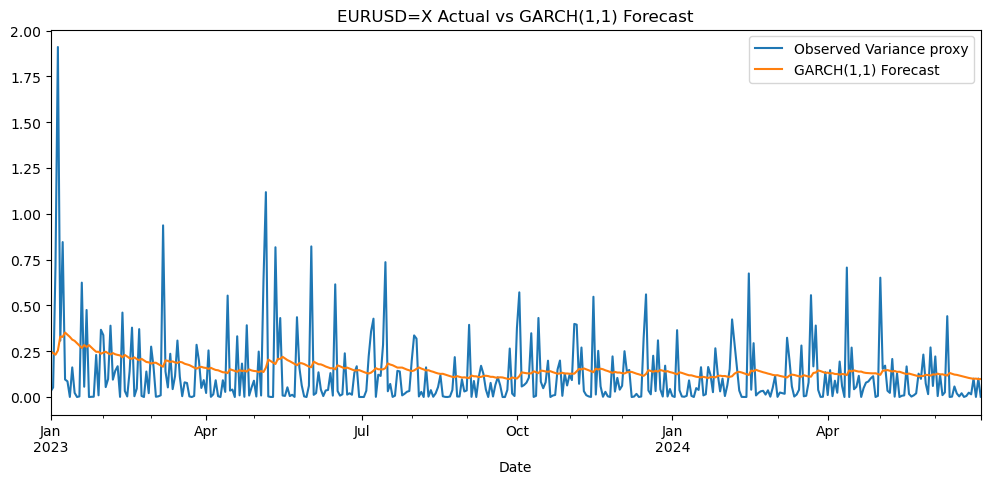

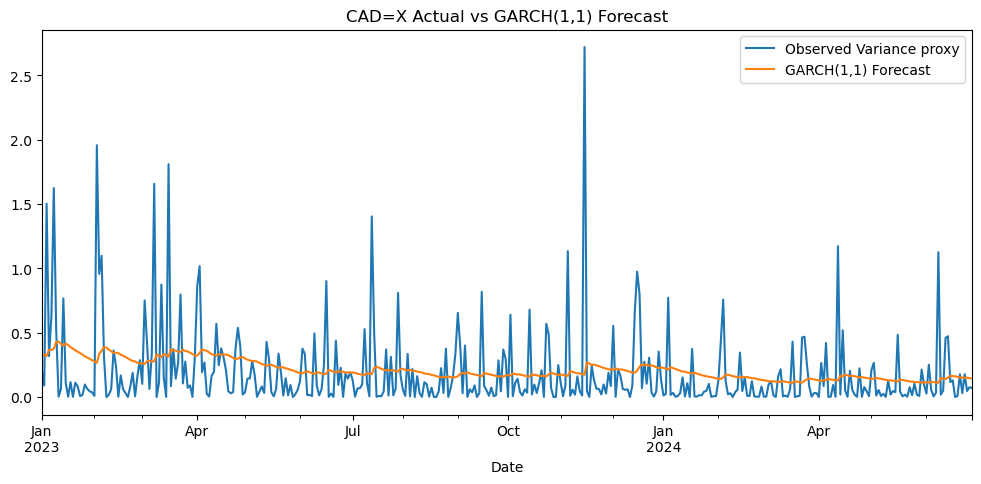

In [14]:
test_sq = test.copy()
test_sq = test_sq**2

for ticker in tickers:
    plt.figure(figsize=(12, 5))
    
    title = f"{ticker} Actual vs GARCH({P},{Q}) Forecast"

    test_sq[ticker].plot(label="Observed Variance proxy")
    preds[ticker].plot(label=f"GARCH({P},{Q}) Forecast")
    
    plt.title(title)

    # save plot 
    plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.legend()
    plt.show()

In [ ]:
results = preds.copy()

new_columns = [] 
for ticker in tickers:
    new_columns.append(f'{ticker}_forecast')

results.columns = new_columns

print(results.info())
results

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 390 entries, 2023-01-02 to 2024-06-28
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EURUSD=X_forecast  390 non-null    float64
 1   CAD=X_forecast     390 non-null    float64
dtypes: float64(2)
memory usage: 17.2 KB
None


,EURUSD=X_forecast,CAD=X_forecast
Date,,
2023-01-02,0.249892,0.332238
2023-01-03,0.239920,0.327828
2023-01-04,0.231058,0.317336
2023-01-05,0.253904,0.366471
2023-01-06,0.330071,0.365275
...,...,...
2024-06-24,0.101961,0.152558
2024-06-25,0.099227,0.148497
2024-06-26,0.100606,0.150310


In [25]:
# save results
results.to_csv(f"../results/forecasts/garch11_forecasts.csv")